# Actividad 3: Taller EDA
1. Escoge un conjunto de datos de tu interés (https://www.kaggle.com/datasets)

2. Utilizando Pandas, realiza:
   - Exploración de datos nulos, datos duplicados, cantidad de filas y
   columnas.
   - Limpieza de datos (Pandas: dropna, fillna, replace, etc.)
   - Filtrado y selección de datos relevantes para tu análisis
   - Transformación de columnas, creación de variables nuevas
   - Agrupaciones y resúmenes (groupby)

3. Formula al menos 5 preguntas de análisis sobre tu conjunto de datos.

4. Responde a las pregunta planteadas con una gráfica (con título, nombres en
los ejes, leyendas, etc) y una breve interpretación.

In [1]:
# Sección de imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kaggle

## 1. Carga de datos

In [2]:
# Descargar el dataset desde Kaggle
!kaggle datasets download -d hugodarwood/epirecipes --unzip

Dataset URL: https://www.kaggle.com/datasets/hugodarwood/epirecipes
License(s): unknown
100%|██████████████████████████████████████| 11.3M/11.3M [00:00<00:00, 18.9MB/s]



In [3]:
# Cargar el dataset en un DataFrame de pandas
df = pd.read_csv('epi_r.csv')
df.head()

,title,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,...,yellow squash,yogurt,yonkers,yuca,zucchini,cookbooks,leftovers,snack,snack week,turkey
0,"Lentil, Apple, and Turkey Wrap",2.500,426.0,30.0,7.0,559.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Potato and Fennel Soup Hodge,3.750,165.0,6.0,7.0,165.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mahi-Mahi in Tomato Olive Sauce,5.000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info(verbose=True) # Tocó poner verbose=True para ver toda la información de las columnas, ya que el dataset tiene 680 columnas

<class 'pandas.DataFrame'>
RangeIndex: 20052 entries, 0 to 20051
Data columns (total 680 columns):
 #    Column                    Dtype  
---   ------                    -----  
 0    title                     str    
 1    rating                    float64
 2    calories                  float64
 3    protein                   float64
 4    fat                       float64
 5    sodium                    float64
 6    #cakeweek                 float64
 7    #wasteless                float64
 8    22-minute meals           float64
 9    3-ingredient recipes      float64
 10   30 days of groceries      float64
 11   advance prep required     float64
 12   alabama                   float64
 13   alaska                    float64
 14   alcoholic                 float64
 15   almond                    float64
 16   amaretto                  float64
 17   anchovy                   float64
 18   anise                     float64
 19   anniversary               float64
 20   anthony bourdai

## 2. ETL

In [5]:
# Ya que son demasiadas columnas y solo necesito unas pocas, voy a seleccionar solo las columnas que me interesan para el análisis
columnas = [
    'title', 
    'rating', 
    'calories', 
    'protein', 
    'fat', 
    'sodium', 
    '22-minute meals', 
    '3-ingredient recipes', 
    '30 days of groceries', 
    'advance prep required'
] # Agregué otras columnas que según entiendo son binarias y pueden ser útiles para el análisis
df = df[columnas]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20052 entries, 0 to 20051
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  20052 non-null  str    
 1   rating                 20052 non-null  float64
 2   calories               15935 non-null  float64
 3   protein                15890 non-null  float64
 4   fat                    15869 non-null  float64
 5   sodium                 15933 non-null  float64
 6   22-minute meals        20052 non-null  float64
 7   3-ingredient recipes   20052 non-null  float64
 8   30 days of groceries   20052 non-null  float64
 9   advance prep required  20052 non-null  float64
dtypes: float64(9), str(1)
memory usage: 1.5 MB


In [6]:
# Metadata general del dataset (Nulos, numero de filas, columnas)
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
print(f"El dataset tiene \n{df.isnull().sum()} \nvalores nulos repartidos en sus columnas.")

El dataset tiene 20052 filas y 10 columnas.
El dataset tiene 
title                       0
rating                      0
calories                 4117
protein                  4162
fat                      4183
sodium                   4119
22-minute meals             0
3-ingredient recipes        0
30 days of groceries        0
advance prep required       0
dtype: int64 
valores nulos repartidos en sus columnas.


In [7]:
# Me deshago de los nulos en las columnas que me interesan
df = df.dropna(subset=['calories', 'protein', 'fat', 'sodium'])
print(f"Filas resultantes: {df.shape[0]} \nNulos restantes: {df.isnull().sum().sum()}")

Filas resultantes: 15864 
Nulos restantes: 0


In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 15864 entries, 0 to 20051
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  15864 non-null  str    
 1   rating                 15864 non-null  float64
 2   calories               15864 non-null  float64
 3   protein                15864 non-null  float64
 4   fat                    15864 non-null  float64
 5   sodium                 15864 non-null  float64
 6   22-minute meals        15864 non-null  float64
 7   3-ingredient recipes   15864 non-null  float64
 8   30 days of groceries   15864 non-null  float64
 9   advance prep required  15864 non-null  float64
dtypes: float64(9), str(1)
memory usage: 1.3 MB


In [9]:
# Como las ultimas 4 columnas son binarias, las convierto a int para facilitar el análisis posterior
binary_columns = [
    '22-minute meals', 
    '3-ingredient recipes', 
    '30 days of groceries', 
    'advance prep required'
]
for col in binary_columns:
    df[col] = df[col].astype(int)
df.head()

,title,rating,calories,protein,fat,sodium,22-minute meals,3-ingredient recipes,30 days of groceries,advance prep required
0,"Lentil, Apple, and Turkey Wrap",2.500,426.0,30.0,7.0,559.0,0,0,0,0
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0,0,0,0
2,Potato and Fennel Soup Hodge,3.750,165.0,6.0,7.0,165.0,0,0,0,0
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0,0,0,0
5,The Best Blts,4.375,948.0,19.0,79.0,1042.0,0,0,0,0


In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 15864 entries, 0 to 20051
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  15864 non-null  str    
 1   rating                 15864 non-null  float64
 2   calories               15864 non-null  float64
 3   protein                15864 non-null  float64
 4   fat                    15864 non-null  float64
 5   sodium                 15864 non-null  float64
 6   22-minute meals        15864 non-null  int64  
 7   3-ingredient recipes   15864 non-null  int64  
 8   30 days of groceries   15864 non-null  int64  
 9   advance prep required  15864 non-null  int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 1.3 MB


### Filtrado y selección de datos relevantes, transformaciones, variables, agrupaciones y resúmenes

In [11]:
# Variables útiles
df_nutritional = df[['calories', 'protein', 'fat', 'sodium']] # Solo las columnas nutricionales
df_good = df[df['rating'] >= 4.0] # Recetas con buena calificación (4 o más estrellas)
df_low_calories = df[df['calories'] < 300] # Recetas bajas en calorías (menos de 300)
df_high_protein = df[df['protein'] > 20] # Recetas altas en proteína (más de 20 gramos)
print(f"Recetas con buena calificación: {df_good.shape[0]}")
print(f"Recetas bajas en calorías: {df_low_calories.shape[0]}")
print(f"Recetas altas en proteína: {df_high_protein.shape[0]}")
print(f"Total de recetas: {df.shape[0]}")

Recetas con buena calificación: 8658
Recetas bajas en calorías: 7097
Recetas altas en proteína: 4820
Total de recetas: 15864


In [12]:
# Transformaciones útiles
df['calories_per_protein'] = df['calories'] / df['protein'] # Calorías por gramo de proteína
df['calories_category'] = pd.cut(
    df['calories'], 
    bins=[0, 200, 400, 600, 800, float('inf')], 
    labels=['low', 'medium-low', 'medium', 'medium-high', 'high']
    ) # Calorías categóricas
df.head()

,title,rating,calories,protein,fat,sodium,22-minute meals,3-ingredient recipes,30 days of groceries,advance prep required,calories_per_protein,calories_category
0,"Lentil, Apple, and Turkey Wrap",2.500,426.0,30.0,7.0,559.0,0,0,0,0,14.200000,medium
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0,0,0,0,22.388889,medium
2,Potato and Fennel Soup Hodge,3.750,165.0,6.0,7.0,165.0,0,0,0,0,27.500000,low
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0,0,0,0,27.350000,medium
5,The Best Blts,4.375,948.0,19.0,79.0,1042.0,0,0,0,0,49.894737,high


In [13]:
# Agrupaciones
mean_calories_by_nutrition = df.groupby('calories_category')[['protein','fat','sodium']].mean() # Por qué el sodio está tan alto???
mean_3ingredient_recipes = df.groupby('3-ingredient recipes')[['calories', 'protein', 'fat', 'sodium']].mean()
mean_advance_prep = df.groupby('advance prep required')[['calories', 'protein', 'fat', 'sodium']].mean()
mean_calories_by_rating = df.groupby('calories_category')[['rating']].mean()
print(mean_calories_by_nutrition)
print(mean_3ingredient_recipes)
print(mean_advance_prep)
print(mean_calories_by_rating)

                      protein          fat        sodium
calories_category                                       
low                  3.220776     5.420776    325.978473
medium-low           9.349409    14.356576    368.423785
medium              20.949446    26.734765    820.921745
medium-high         31.258003    39.823944    913.140845
high               632.154804  2344.041370  41009.544484
                         calories     protein         fat       sodium
3-ingredient recipes                                                  
0                     6358.163974  100.428048  347.393651  6259.822204
1                      424.250000   18.350000   24.700000   644.050000
                          calories     protein         fat       sodium
advance prep required                                                  
0                      6377.173200  100.649611  348.423216  6277.505604
1                       620.452055   30.013699   36.273973   896.068493
                     rating
c

In [14]:
df['calories_category'].value_counts() # Tratando de ver por qué salen tan altos algunos valores

calories_category
medium-low     5163
low            3995
medium         2888
high           2248
medium-high    1562
Name: count, dtype: int64

In [15]:
print(f"Maximo de sodio: {df['sodium'].max()}")
print(f"Maximo de grasa: {df['fat'].max()}")
print(f"Maximo de proteina: {df['protein'].max()}")
# Este dataset tiene unos outliers muy groseros jajaja

Maximo de sodio: 27675110.0
Maximo de grasa: 1722763.0
Maximo de proteina: 236489.0


In [16]:
df.groupby('calories_category')[['protein','fat','sodium']].median() # Con la mediana se ve más razonable

,protein,fat,sodium
calories_category,,,
low,2.0,5.0,79.0
medium-low,6.0,14.0,207.0
medium,17.0,26.0,415.5
medium-high,29.0,40.0,600.0
high,57.0,71.0,996.0


## 3. Formulación de preguntas
- ¿La gente disfruta más de recetas con alto contenido calórico?
- ¿Qué hace que una receta tenga más o menos calorías? (según este dataset porque está como raro)
- ¿La gente prefiere recetas rápidas?
- ¿Cuáles son las mejores recetas en función de calorías por proteína?
- ¿Las recetas más saludables reciben mejores valoraciones?

### 4. Respuestas

### ¿La gente disfruta más de recetas con alto contenido calórico?

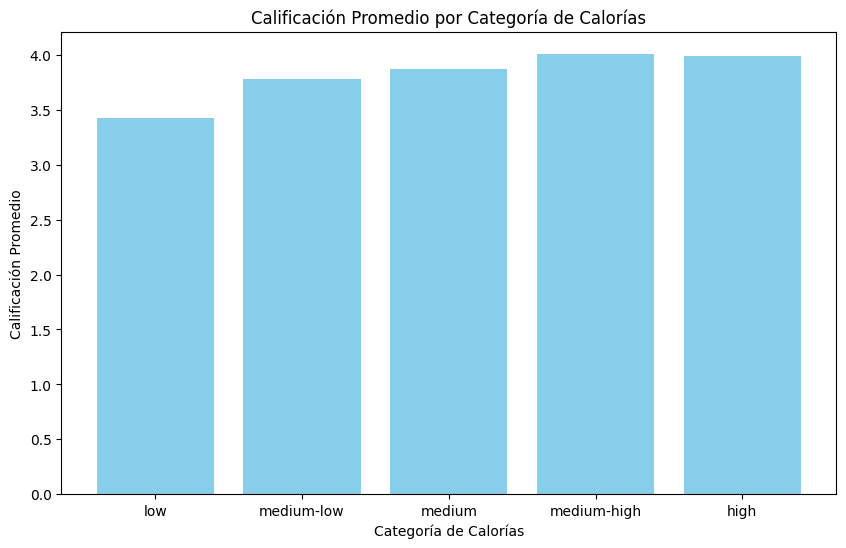

In [17]:
# Aqui voy a utilizar un gráfico de barras con calorías categóricas por rating
plt.figure(figsize=(10,6))
plt.bar(mean_calories_by_rating.index, mean_calories_by_rating['rating'], color='skyblue')
plt.xlabel('Categoría de Calorías')
plt.ylabel('Calificación Promedio')
plt.title('Calificación Promedio por Categoría de Calorías')
plt.show()

Al parecer a las personas les gustan más las recetas entre 600 y 800 calorías que fue como lo acomodamos arriba en la sección de transformaciones.

### ¿Qué hace que una receta tenga más o menos calorías?

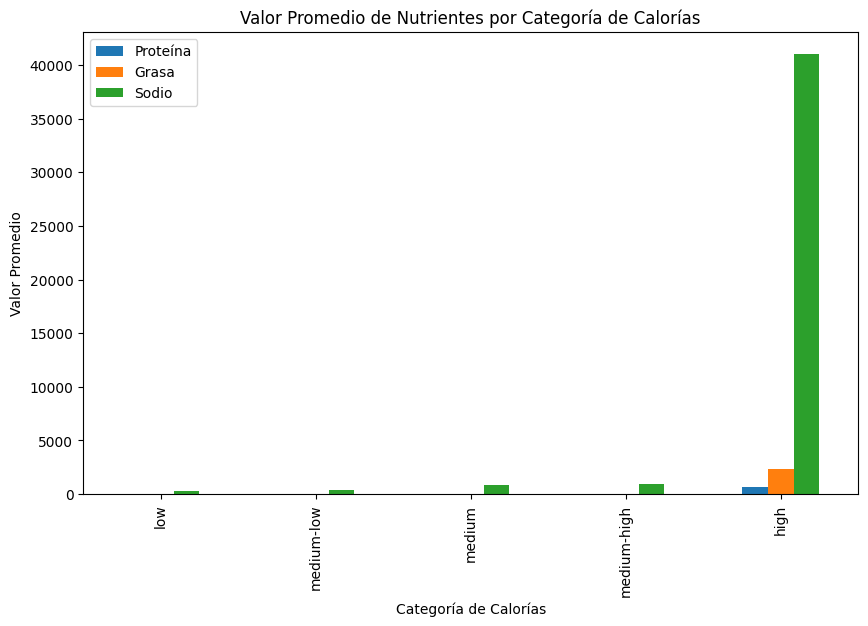

In [18]:
# En esta voy a utilizar otro gráfico de barras de categorías categóricas por nutrición
mean_calories_by_nutrition.plot(kind='bar', figsize=(10,6))
plt.xlabel('Categoría de Calorías')
plt.ylabel('Valor Promedio')
plt.title('Valor Promedio de Nutrientes por Categoría de Calorías')
plt.legend(['Proteína', 'Grasa', 'Sodio'])
plt.show()

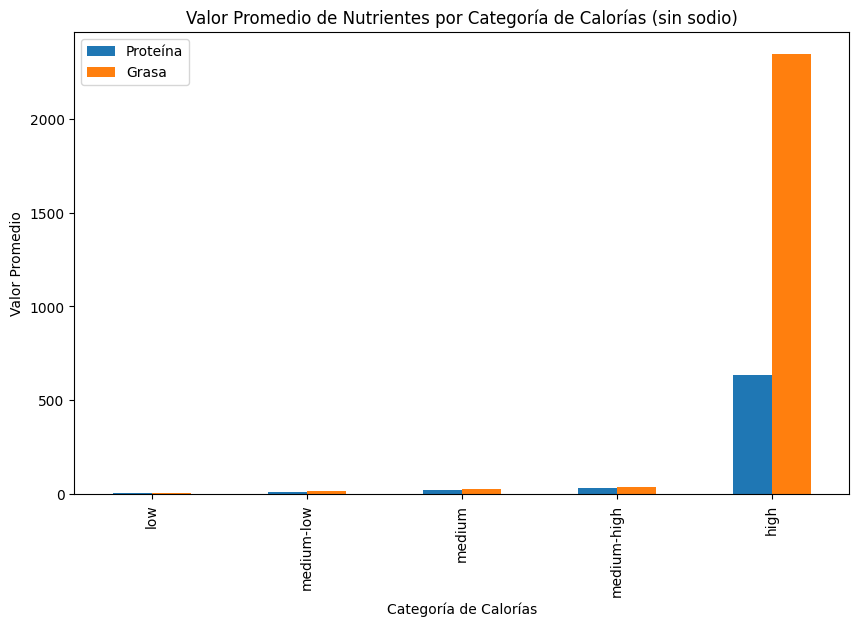

In [19]:
# Voy a agrupar de nuevo pero sin sodio a ver si se ve más normal
mean_calories_by_nutrition_no_sodium = df.groupby('calories_category')[['protein','fat']].mean()
mean_calories_by_nutrition_no_sodium.plot(kind='bar', figsize=(10,6))
plt.xlabel('Categoría de Calorías')
plt.ylabel('Valor Promedio')
plt.title('Valor Promedio de Nutrientes por Categoría de Calorías (sin sodio)')
plt.legend(['Proteína', 'Grasa'])
plt.show()

Bueno, en este caso ya tiene más sentido que sea la grasa lo que más afecte a las calorías, puede que con otro tipo de gráfico se vea mejor.

### ¿La gente prefiere recetas rápidas?

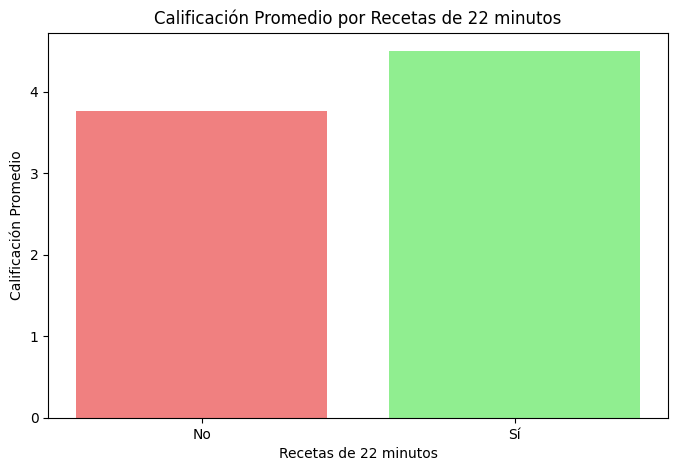

In [20]:
# Para esta voy a hacer un gráfico de rating por la binaria de 22-minute meals, 
# pero tengo que hacer otra agrupación porque no la consideré antes
mean_rating_by_22min = df.groupby('22-minute meals')[['rating']].mean()
plt.figure(figsize=(8,5))
plt.bar(mean_rating_by_22min.index.astype(str), mean_rating_by_22min['rating'], color=['lightcoral', 'lightgreen'])
plt.xlabel('Recetas de 22 minutos')
plt.ylabel('Calificación Promedio')
plt.title('Calificación Promedio por Recetas de 22 minutos')
plt.xticks([0, 1], ['No', 'Sí'])
plt.show()


Esto sería ideal si tuviéramos una columna de "veces preparada", ya que podríamos darnos cuenta si realmente se preparan más veces recetas rápidas, pero la calificación basta para decir que si.

### ¿Cuáles son las mejores recetas en función de calorías por proteína?

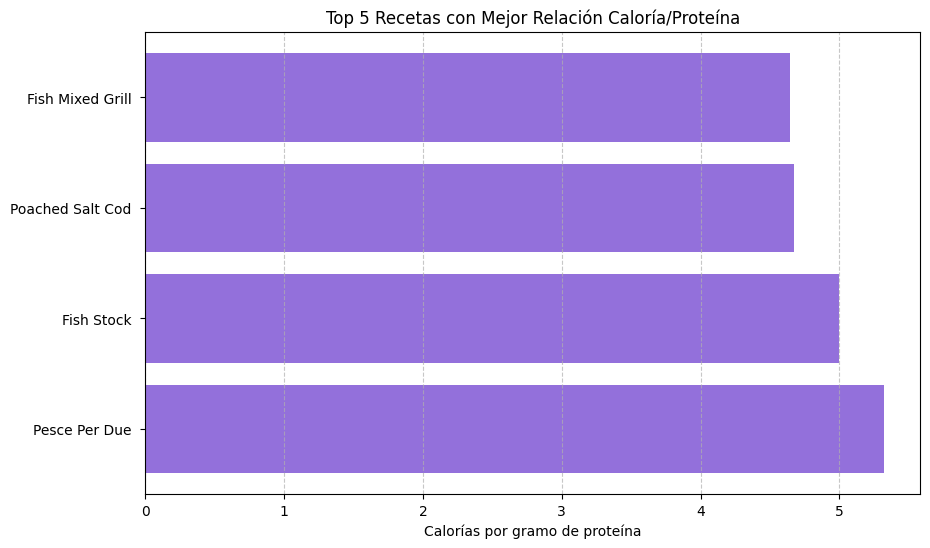

In [21]:
# Aquí voy a hacr un top 5 de las recetas con mejor relación caloría/proteína
top_5_calories_per_protein = df.sort_values('calories_per_protein').head(5)[['title', 'calories_per_protein']]
plt.figure(figsize=(10,6))
plt.barh(top_5_calories_per_protein['title'], top_5_calories_per_protein['calories_per_protein'], color='mediumpurple')
plt.xlabel('Calorías por gramo de proteína')
plt.title('Top 5 Recetas con Mejor Relación Caloría/Proteína')
plt.gca().invert_yaxis() # la mejor receta queda arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Ya aquí podemos ver que "Fish Mixed Grill" se lleva la corona con poco más de 4.5 calorías por gramo de proteína.

### ¿Las recetas más saludables reciben mejores valoraciones?

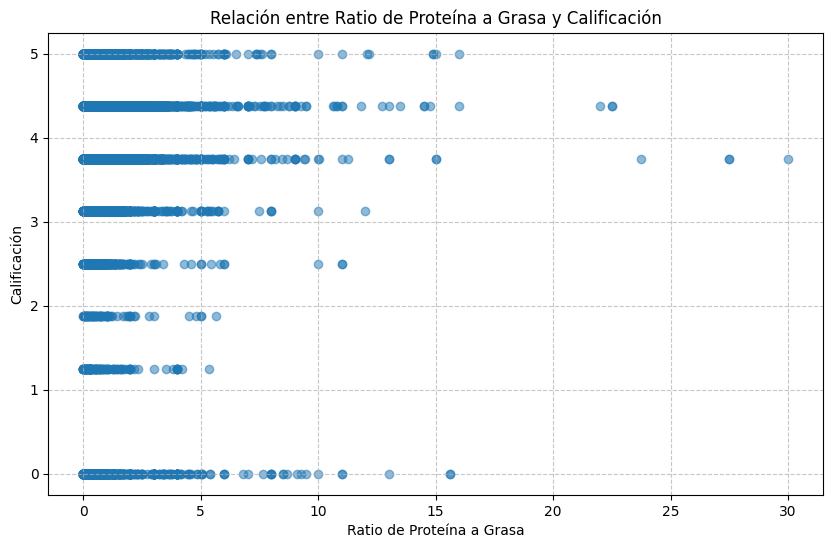

In [22]:
# En esta podemos primero hacer una columna para el ratio de proteinas por grasa y luego acomodarlas por rating en un gráfico de dispersión

df['protein_to_fat_ratio'] = df['protein'] / df['fat']
plt.figure(figsize=(10,6))
plt.scatter(df['protein_to_fat_ratio'], df['rating'], alpha=0.5)
plt.xlabel('Ratio de Proteína a Grasa')
plt.ylabel('Calificación')
plt.title('Relación entre Ratio de Proteína a Grasa y Calificación')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


En este se pueden apreciar muchos outliers pero se ve que la mayoría de recetas están entre 0 a 5 gramos de proteína por gramo de grasa y los datos están algo "equilibrados" salvo esa gran cantidad de rectas con 0 estrellas, pero se mantiene estable entre 4 y 4.5 estrellas en un ratio entre 0 y 15 gramos de proteína por gramo de grasa.